In [15]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import eq
import numpy as np
import matplotlib.pyplot as plt
import concurrent
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading the catalog
We load the catalog like in the previous notebook.

In [22]:
# !rm -rf /home/gcl/RB/kdascher/Projects/MAG_RECAST/recast/data/ANSS_MultiCatalog
catalog = eq.catalogs.ANSS_MultiCatalog(    
    num_sequences=5000,
    t_end_days=365,
    radius_kilometers=250,
    mag_completeness=4.5,
    minimum_mainshock_mag=6.5,
)

Loading existing catalog from /Users/kdascher/Documents/Documents/Berkeley/Projects/DS_discovery/recast/data/ANSS_MultiCatalog.


## Loading a trained model
All models trained on the default versions of the catalog are stored in `{PROJECT_ROOT_DIR}/trained_models/`.

In [17]:
trained_models_dir = Path(eq.__file__).parents[1] / "trained_models"
trained_models_dir

PosixPath('/Users/kdascher/Documents/Documents/Berkeley/Projects/DS_discovery/recast/trained_models')

In [18]:
# model = eq.models.RecurrentTPP.load_from_checkpoint(trained_models_dir / "White_RecurrentTPP.ckpt")
filename ='/Users/kdascher/Documents/Documents/Berkeley/Projects/DS_discovery/recast/notebooks/kelian/lightning_logs/version_38/checkpoints/epoch=166-step=5010.ckpt'
# filename ='epoch=54-step=660.ckpt'
model = eq.models.RecurrentTPP.load_from_checkpoint(filename)
model.eval()

RecurrentTPP(
  (hypernet_time): Linear(in_features=32, out_features=96, bias=True)
  (hypernet_mag): Linear(in_features=32, out_features=1, bias=True)
  (rnn): GRU(2, 32, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

## Turing tests of the model's forecast

Here we explore the model's forecasts. As a first experiment, I will look the model's 'productivity law'. 

For every sequence in the validation set, we identify the mainshock as the largest event in the sequence, then we generate a forcast with length `duration` triggered after `dt` days. The forecast comprises `num_samples` continuations. From these continuations, we can compute the distribution of the total number of events in the forecast window. We can then compare this distribution to the productivity law derived by kdc 2018. 

In [20]:
def productivity_law_forecast(model, dataset, dt=0, duration=14, num_samples=2000):
    mainshock_magnitudes = []
    forecast_counts = []
    actual_counts = []

    def process_sequence(seq):
        mainshock_index = (seq.mag * (seq.arrival_times > seq.t_nll_start)).argmax()
        t_forecast = seq.arrival_times[mainshock_index]

        if t_forecast + dt + duration > seq.t_end:
            return None

        past_seq = seq.get_subsequence(0, t_forecast+dt)
        observed_seq = seq.get_subsequence(t_forecast+dt, t_forecast+dt + duration)
        forecast = model.sample(batch_size=min(2000, num_samples), duration=duration, past_seq=past_seq, return_sequences=True)
        counts = [len(seq) for seq in forecast]
        return (
            seq.mag[mainshock_index],
            counts,
            len(observed_seq),
        )

    results = []
    # Limit number of workers to avoid resource exhaustion
    max_workers = min(8, os.cpu_count() or 1)
    with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(process_sequence, seq) for seq in dataset]
        for f in concurrent.futures.as_completed(futures):
            result = f.result()
            if result is not None:
                results.append(result)

    # Unpack the results
    mainshock_magnitudes, forecast_counts, actual_counts = zip(*results) if results else ([], [], [])

    mainshock_magnitudes = list(mainshock_magnitudes)
    forecast_counts = list(forecast_counts)
    actual_counts = list(actual_counts)
    
    return mainshock_magnitudes, forecast_counts, actual_counts


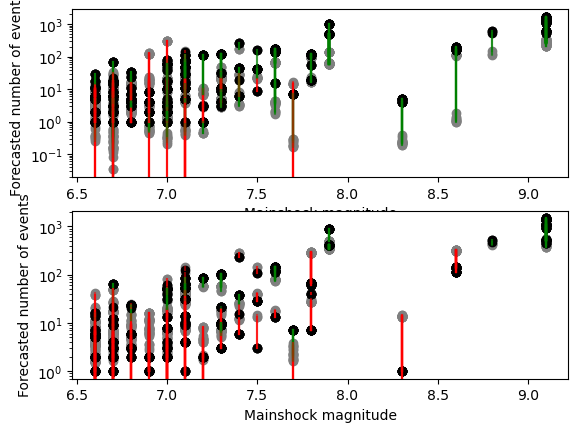

In [ ]:
fig, ax = plt.subplots(2,1)

def vizualize_productivity_law(mainshock_magnitudes, forecast_counts, actual_counts, ax):
    ax.scatter(
        mainshock_magnitudes,
        [np.mean(fc) for fc in forecast_counts],
        c='grey',
    )

    ax.scatter(
        mainshock_magnitudes,
        actual_counts,
        c='k',
    )

    for i, (mag, fc, ac) in enumerate(zip(mainshock_magnitudes, [np.mean(fc) for fc in forecast_counts], actual_counts)):
        ax.plot([mag, mag], [fc, ac], c='r' if fc > ac else 'g', alpha=0.5)

    ax.set(
        xlabel='Mainshock magnitude',
        ylabel='Forecasted number of events',
        yscale='log',
    )
    
for iax, dt in zip(ax, [0, 0.2]):
    mainshock_magnitudes, forecast_counts, actual_counts = productivity_law_forecast(model, catalog.val, dt=dt)
    vizualize_productivity_law(mainshock_magnitudes, forecast_counts, actual_counts, iax)

plt.tight_layout()
